In [1]:
# Import libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
import torch
import torch.nn as nn

In [3]:
# IXI dataset
ixi_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\image slice-T2"

# BraTS2020 Training and Validation datasets
brats_train_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"
brats_val_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_ValidationData\MICCAI_BraTS2020_ValidationData"


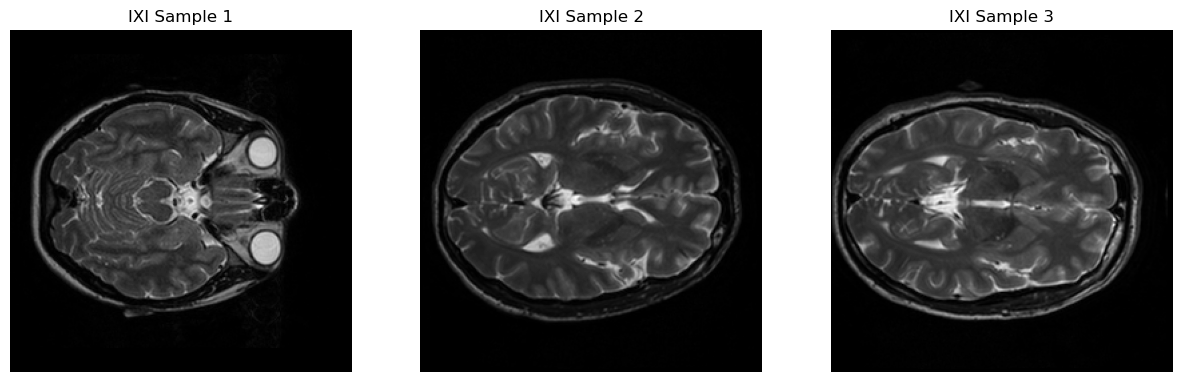

In [4]:
# IXI dataset
def load_ixi_sample(path, num_samples=3):
    folders = os.listdir(path)
    sample_images = []
    for folder in folders[:num_samples]:  
        folder_path = os.path.join(path, folder)
        image_files = os.listdir(folder_path)
        first_image = os.path.join(folder_path, image_files[0])  
        img = Image.open(first_image)
        sample_images.append(np.array(img))
    return sample_images

ixi_samples = load_ixi_sample(ixi_path)

# Plot the samples
plt.figure(figsize=(15, 5))
for i, sample in enumerate(ixi_samples):
    plt.subplot(1, len(ixi_samples), i + 1)
    plt.imshow(sample, cmap='gray')
    plt.title(f"IXI Sample {i + 1}")
    plt.axis('off')
plt.show()

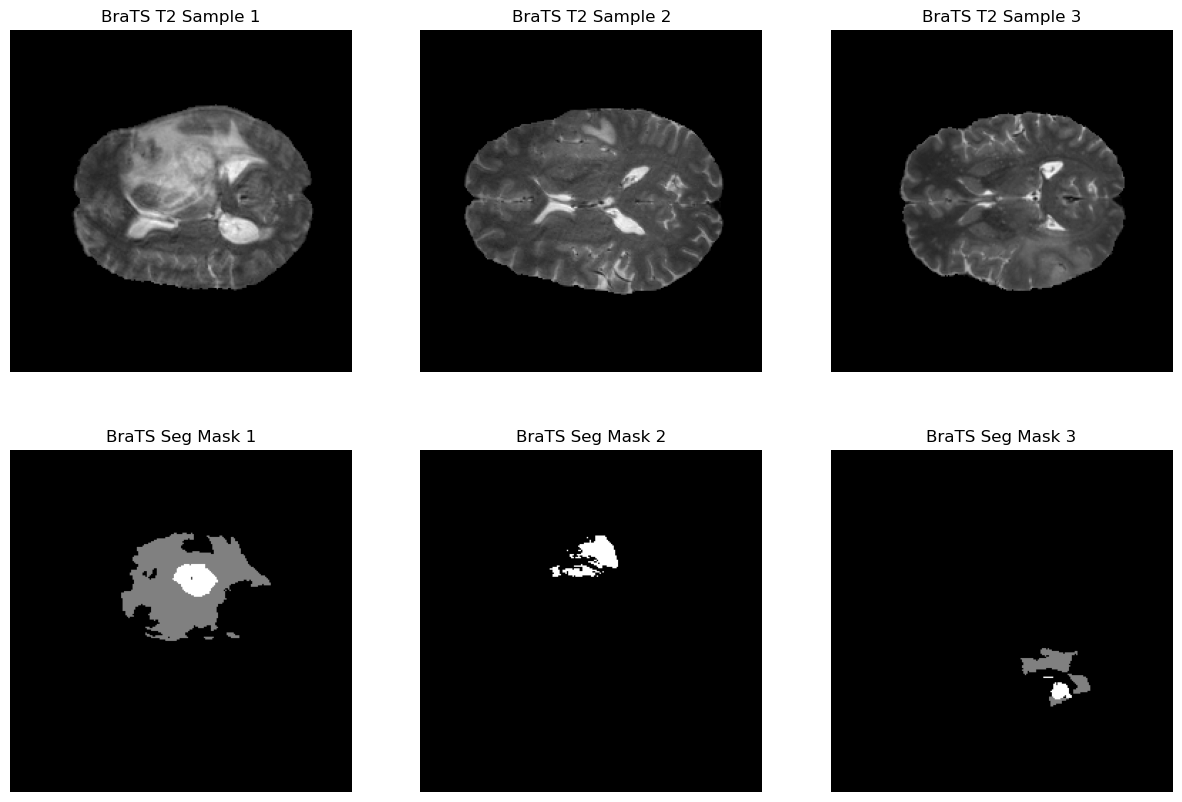

In [12]:
# BraTS2020
def load_brats_sample(path, num_samples=3):
    folders = os.listdir(path)
    images, masks = [], []
    for folder in folders[:num_samples]: 
        folder_path = os.path.join(path, folder)
        t2_image = nib.load(os.path.join(folder_path, f"{folder}_t2.nii")).get_fdata()
        seg_image = nib.load(os.path.join(folder_path, f"{folder}_seg.nii")).get_fdata()
        # middle slice 
        middle_slice = t2_image.shape[2] // 2
        images.append(t2_image[:, :, middle_slice])
        masks.append(seg_image[:, :, middle_slice])
    return images, masks

brats_images, brats_masks = load_brats_sample(brats_train_path)

# Plot the samples
plt.figure(figsize=(15, 10))
for i, (image, mask) in enumerate(zip(brats_images, brats_masks)):
    plt.subplot(2, len(brats_images), i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"BraTS T2 Sample {i + 1}")
    plt.axis('off')
    
    plt.subplot(2, len(brats_images), i + 1 + len(brats_images))
    plt.imshow(mask, cmap='gray')
    plt.title(f"BraTS Seg Mask {i + 1}")
    plt.axis('off')
plt.show()

In [5]:
# Encoder and Decoder
import torch
import torch.nn as nn

# Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 32 * 32, latent_dim)  # Mean
        self.fc_logvar = nn.Linear(128 * 32 * 32, latent_dim)  # Log variance

    def forward(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


# Decoder 
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 128 * 32 * 32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        z = self.fc(z)
        z = z.view(-1, 128, 32, 32)
        return self.decoder(z)


In [6]:
# VAE Model

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


In [7]:
# Loss Functions

def compute_loss(x, x_hat, mu, logvar):
    # Reconstruction (L1 loss)
    recon_loss = torch.mean(torch.abs(x - x_hat))

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss
    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss


In [8]:
# IXI Loader

import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class IXIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        folders = os.listdir(root_dir)
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            for file in os.listdir(folder_path):
                if file.endswith(".png"):  
                    self.samples.append(os.path.join(folder_path, file))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]
        image = Image.open(img_path).convert("L")  
        if self.transform:
            image = self.transform(image)
        return image


transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor()          # Convert to tensor
])

ixi_dataset = IXIDataset(r"C:\Users\user\Desktop\MASTER\NN\HW6\image slice-T2", transform=transform)
ixi_loader = DataLoader(ixi_dataset, batch_size=4, shuffle=True)


In [10]:
# Training

from tqdm import tqdm
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
num_epochs = 20

# loop
losses = []
vae.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    with tqdm(total=len(ixi_loader), desc=f"Epoch {epoch + 1}/{num_epochs}") as pbar:
        for batch_idx, images in enumerate(ixi_loader):
            images = images.to(device)
            optimizer.zero_grad()
            
            # Forward 
            reconstructed, mu, logvar = vae(images)
            
            # loss
            total_loss, recon_loss, kl_loss = compute_loss(images, reconstructed, mu, logvar)
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            pbar.set_postfix({"Batch Loss": total_loss.item()})
            pbar.update(1)
    
    avg_loss = epoch_loss / len(ixi_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} completed. Average Loss: {avg_loss:.4f}")


Epoch 1/20: 100%|██████████| 7213/7213 [08:27<00:00, 14.21it/s, Batch Loss=0.0586]


Epoch 1/20 completed. Average Loss: 0.1707


Epoch 2/20: 100%|██████████| 7213/7213 [05:05<00:00, 23.64it/s, Batch Loss=0.0528]


Epoch 2/20 completed. Average Loss: 0.0503


Epoch 3/20: 100%|██████████| 7213/7213 [05:03<00:00, 23.79it/s, Batch Loss=0.0487]


...

Epoch 18/20 completed. Average Loss: 0.0498


Epoch 19/20: 100%|██████████| 7213/7213 [05:03<00:00, 23.78it/s, Batch Loss=0.045] 


Epoch 19/20 completed. Average Loss: 0.0498


Epoch 20/20: 100%|██████████| 7213/7213 [05:00<00:00, 23.97it/s, Batch Loss=0.0411]

Epoch 20/20 completed. Average Loss: 0.0498


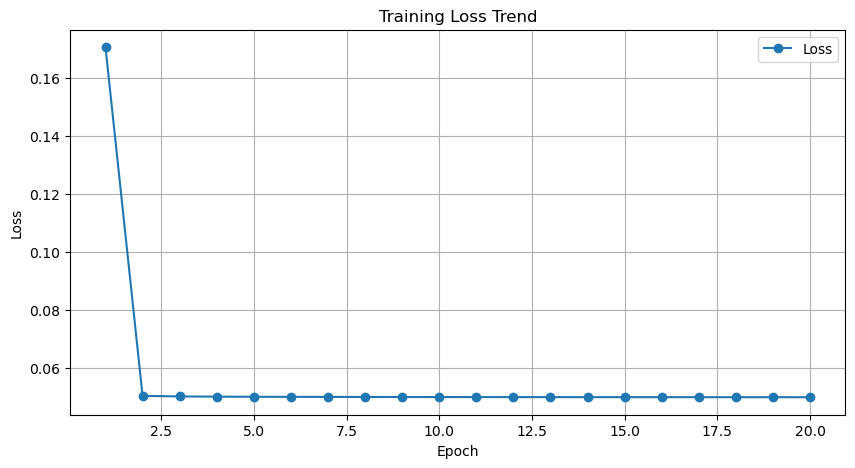

In [11]:
# Loss plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), losses, marker='o', label="Loss")
plt.title("Training Loss Trend")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()


Sample 1 (Random Slice) - Dice Coefficient: 0.6175


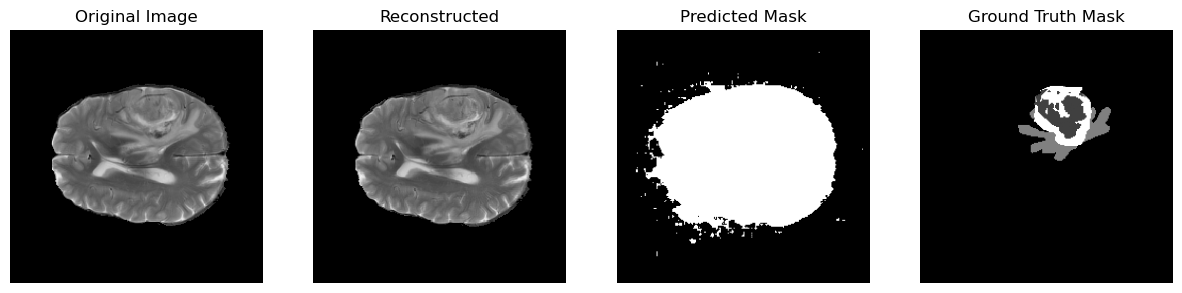

Sample 2 (Random Slice) - Dice Coefficient: 0.0000


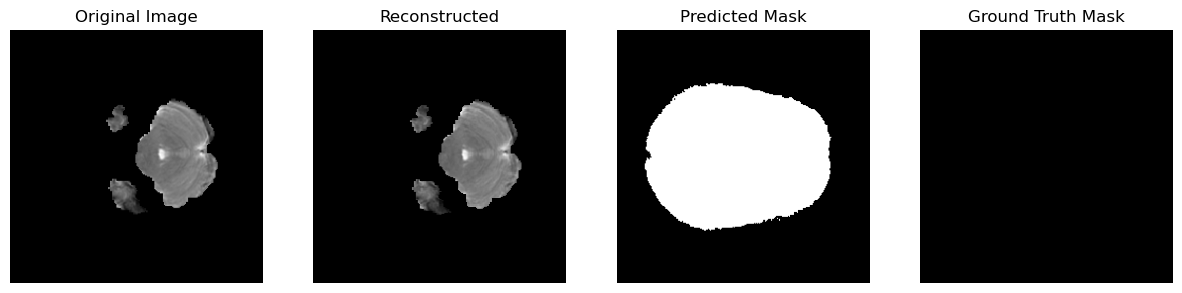

Sample 3 (Random Slice) - Dice Coefficient: 0.1218


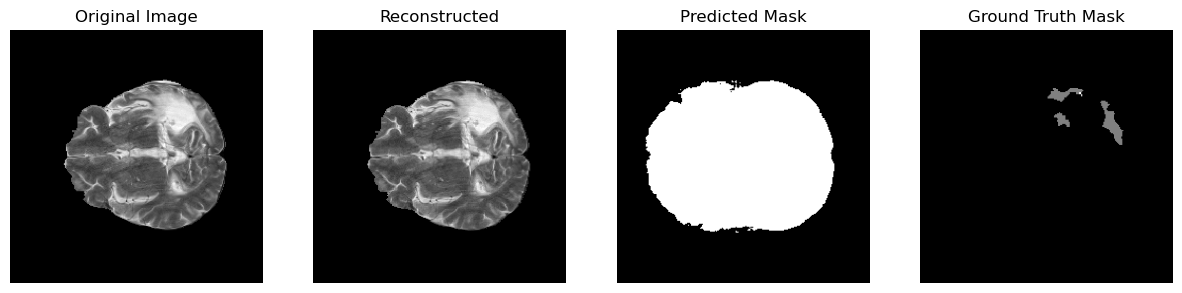

In [34]:
# Test VAE Model on Random BraTS Data

import random
import torch.nn.functional as F

def dice_coefficient(y_true, y_pred):
    
    smooth = 1e-6
    intersection = (y_true * y_pred).sum()
    dice = (2. * intersection + smooth) / (y_true.sum() + y_pred.sum() + smooth)
    return dice

vae.eval()

num_random_samples = 3  # Number of random samples to test
folders = os.listdir(brats_train_path)
selected_folders = random.sample(folders, num_random_samples)

random_images, random_masks = [], []
for folder in selected_folders:
    folder_path = os.path.join(brats_train_path, folder)
    t2_image = nib.load(os.path.join(folder_path, f"{folder}_t2.nii")).get_fdata()
    seg_image = nib.load(os.path.join(folder_path, f"{folder}_seg.nii")).get_fdata()
    
    # Select a random slice from the 3D file
    random_slice = random.randint(0, t2_image.shape[2] - 1)
    random_images.append(t2_image[:, :, random_slice])
    random_masks.append(seg_image[:, :, random_slice])


for i, (image, mask) in enumerate(zip(random_images, random_masks)):
    # Preprocess image
    image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  
    image_tensor = F.interpolate(image_tensor, size=(256, 256))  

    with torch.no_grad():
        reconstructed, _, _ = vae(image_tensor)
    
    residual = torch.abs(image_tensor - reconstructed).squeeze().cpu().numpy()
    
    # Threshold 
    threshold = 0.1 
    predicted_mask = (residual > threshold).astype(float)
    
    ground_truth_mask = F.interpolate(
        torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0), size=(256, 256)
    ).squeeze().numpy()
    
    # Compute DICE score
    dice = dice_coefficient(ground_truth_mask, predicted_mask)
    print(f"Sample {i + 1} (Random Slice) - Dice Coefficient: {dice:.4f}")
    
    # Plot the results
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(residual, cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(predicted_mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(mask, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')
    plt.show()
